# Visualisasi & Temuan — BDC Tel-U 2026

Notebook ini **menampilkan dan menafsirkan**; ia tidak memuat logika grafik.
Seluruh kode plot ada di `src/viz.py`, sehingga hanya ada satu sumber kebenaran
dan tidak perlu menyelaraskan dua versi setiap kali ada perubahan.

Prasyarat: `python run_all.py` sudah dijalankan.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))

import pandas as pd
from IPython.display import Image, display

import viz
from common import FEATURES_DIR, OUTPUTS_DIR

viz.main()                      # menulis ulang seluruh grafik ke outputs/figures/
FIG = OUTPUTS_DIR / "figures"


membuat grafik ke C:\Users\LENOVO\OneDrive\Documents\BDC\BDC_Tel-U_2026\outputs\figures ...


  + 01_distribusi_label.png


  + 02_cakupan_data.png


  + 03_kata_pembeda.png


  + 04_ablation.png


  + 05_confusion_matrix.png
  + 06_plafon_derau_label.png
selesai.


---
## 1. Masalah utamanya bukan model, tapi datanya

Tiga hal terlihat sekaligus: distribusinya sangat timpang, `Surprise` sendirian
menguasai 41,2% data, dan dua kelas hanya punya satu sampel.

Konsekuensi yang menentukan seluruh sisa pekerjaan: **menebak `Surprise` untuk
semua baris sudah memberi 41,2% akurasi.** Itu ambang yang harus dilewati agar
sebuah model bisa disebut belajar sesuatu.

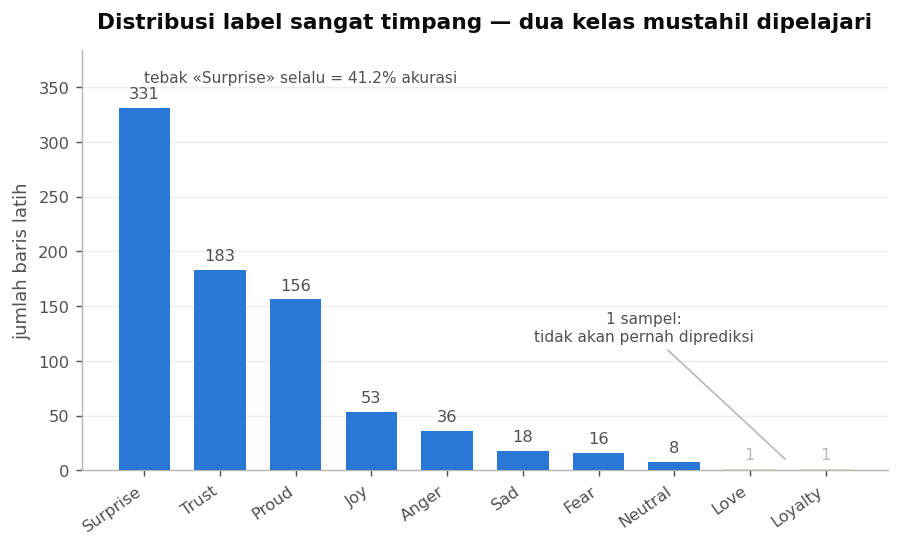

baseline kelas mayoritas : 41.2%


kelas dengan <20 sampel  : 5 dari 10


In [2]:
display(Image(str(FIG / "01_distribusi_label.png")))

tr = pd.read_parquet(FEATURES_DIR / "dataset.parquet").query("split == 'train'")
n = tr.emotion.value_counts()
print(f"baseline kelas mayoritas : {n.iloc[0] / len(tr) * 100:.1f}%")
print(f"kelas dengan <20 sampel  : {(n < 20).sum()} dari {len(n)}")


---
## 2. Data mentahnya cuma tautan — dan sebagiannya sudah mati

Dataset hanya memberi URL. Seluruh fitur harus dibangun sendiri dengan mengunduh
kontennya, dan sebagian tautan sudah tidak bisa diakses sejak dataset disusun.

Panel kanan menjelaskan mengapa transkripsi Whisper dikerjakan lebih dulu
daripada fitur visual: **caption hanya ada di 62,6% baris, transkrip mencakup
87,5%.** Bukan karena lebih canggih, tapi karena menutup celah cakupan.

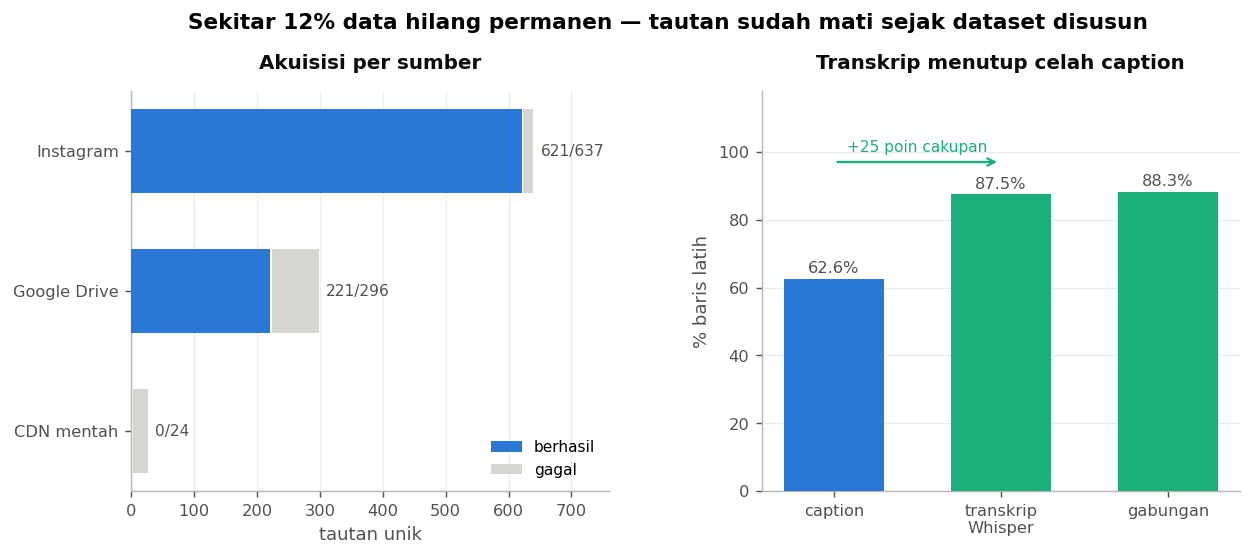

train: 94 baris tanpa konten
sebab
Drive: file dihapus                                  62
CDN: URL kadaluarsa (403)                            21
IG: HTTP 400 (post mati/dibatasi)                     5
IG: empty media (post mati)                           3
IG: DownloadError: ERROR: [Instagram] DKUTIIdRszz     1
IG: dihapus/private                                   1
IG: DownloadError: ERROR: [Instagram] DMj2HkQKSl_     1

test: 25 baris tanpa konten
sebab
Drive: file dihapus              13
CDN: URL kadaluarsa (403)         6
IG: empty media (post mati)       4
Link folder, bukan file video     1
IG: dihapus/private               1



In [3]:
display(Image(str(FIG / "02_cakupan_data.png")))

for split in ("train", "test"):
    g = pd.read_csv(f"../data/gagal_{split}.csv", encoding="utf-8-sig")
    print(f"{split}: {len(g)} baris tanpa konten")
    print(g.sebab.value_counts().to_string())
    print()


---
## 3. Temuan terpenting: label melacak TOPIK, bukan kata emosi

Ini membalik pendekatan yang tampak paling wajar di awal.

Leksikon emosi Bahasa Indonesia yang dirakit manual (*bangga*, *kaget*,
*kecewa*, …) **gagal**: dari lima kelas terbesar, hanya `lex_anger` yang
menempatkan kelasnya sendiri di peringkat teratas.

Analisis log-odds menjelaskan sebabnya. Kata yang paling membedakan tiap kelas
sama sekali bukan kata emosi, melainkan kata topik. Anotator rupanya melabeli
**jenis konten**, bukan nuansa perasaan di captionnya.

Karena itu TF-IDF — yang menangkap topik — bekerja lebih baik daripada pencarian
kata emosi, dan itulah dasar model final.

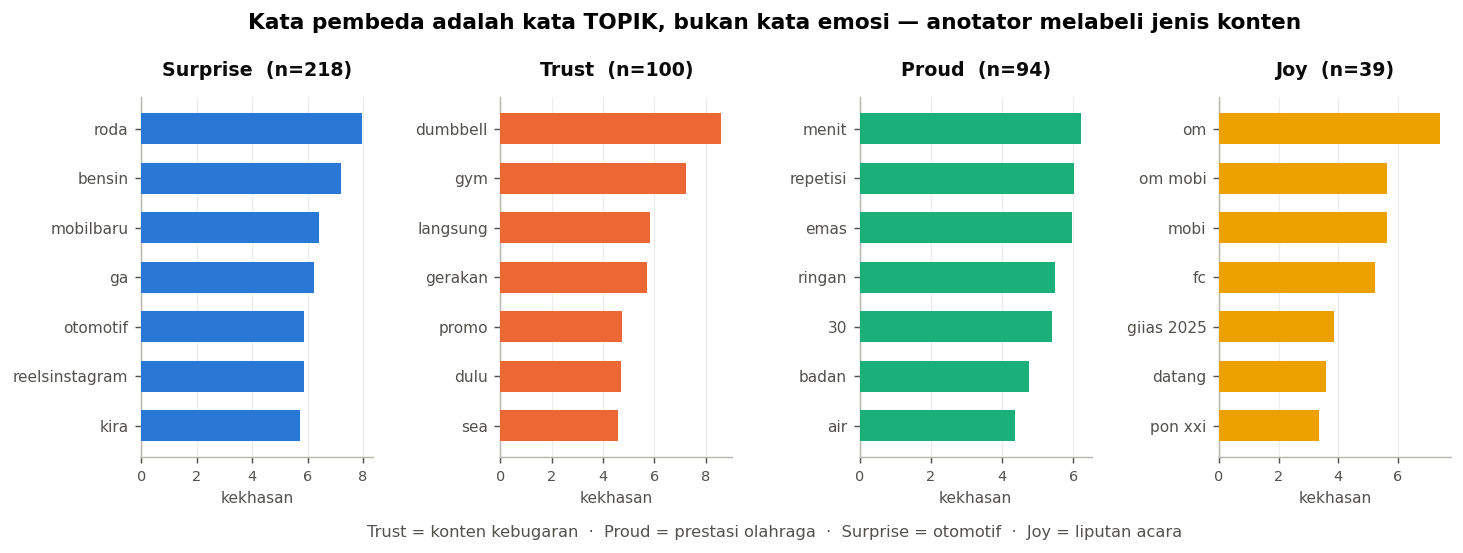

In [4]:
display(Image(str(FIG / "03_kata_pembeda.png")))

---
## 4. Tangga model: apa yang benar-benar menyumbang

Dibaca dari atas ke bawah. Tujuh tahap pertama menumpuk fitur buatan tangan di
atas LightGBM; tahap terakhir membuang semuanya dan hanya memakai TF-IDF pada
gabungan caption + transkrip.

Dua hal yang mengejutkan:

1. **Fitur numerik menurunkan akurasi, bukan sekadar tidak membantu.** Tahap 2–7
   semuanya berada di bawah baseline.
2. **Model paling sederhana justru menang.** Membuang metadata, engagement, dan
   seluruh fitur akustik menaikkan akurasi ke atas baseline.

Grafik ini sengaja dipisah dua panel, bukan satu grafik bersumbu ganda: akurasi
(persen) dan macro-F1 (0–1) punya skala berbeda, dan menumpuknya pada satu sumbu
akan memunculkan hubungan yang tidak ada di datanya.

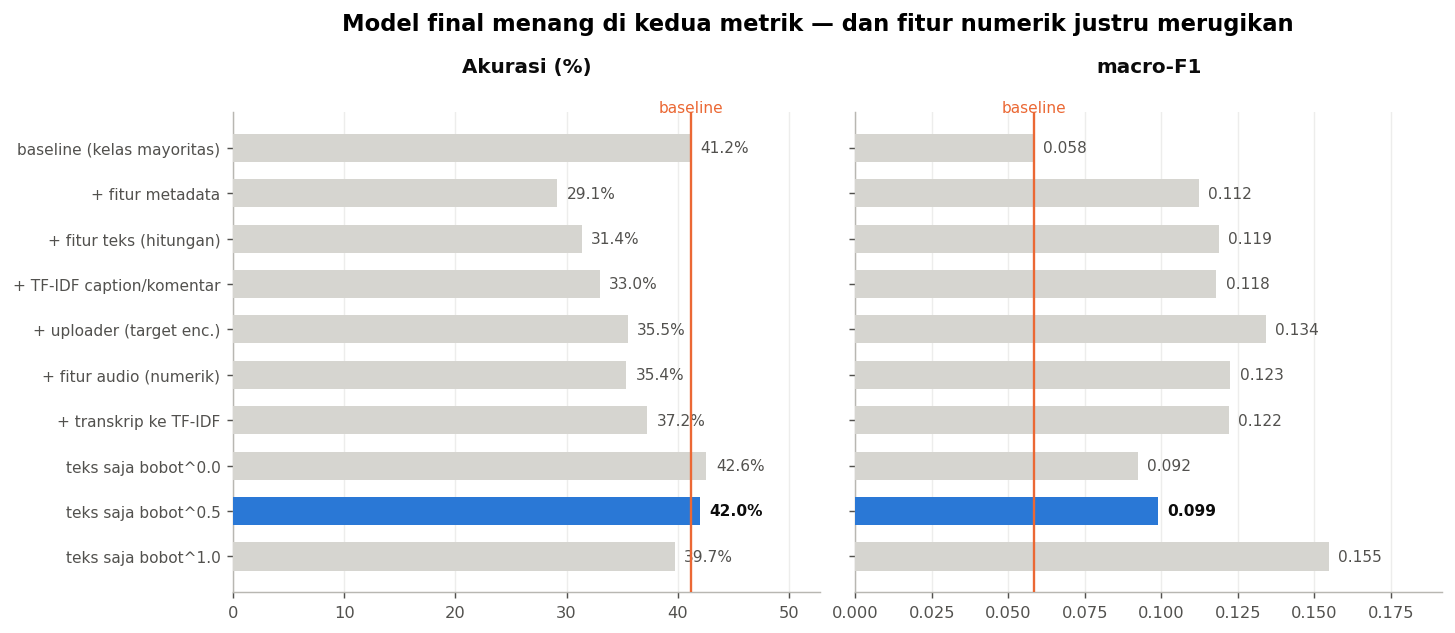

                                  tahap  accuracy  macro_f1  weighted_f1
          1. baseline (kelas mayoritas)  0.412204  0.058377     0.240634
                    2. + fitur metadata  0.291407  0.112245     0.286891
             3. + fitur teks (hitungan)  0.313823  0.118768     0.302911
           4. + TF-IDF caption/komentar  0.330012  0.117976     0.302934
            5. + uploader (target enc.)  0.354919  0.134193     0.324957
             6. + fitur audio (numerik)  0.353674  0.122591     0.320660
               7. + transkrip ke TF-IDF  0.372354  0.122132     0.336839
8. teks saja (TF-IDF+LogReg), bobot^0.0  0.425903  0.092398     0.315825
8. teks saja (TF-IDF+LogReg), bobot^0.5  0.419676  0.098980     0.325386
8. teks saja (TF-IDF+LogReg), bobot^1.0  0.397260  0.154648     0.360982


In [5]:
display(Image(str(FIG / "04_ablation.png")))
print(pd.read_csv(OUTPUTS_DIR / "ablation.csv").to_string(index=False))

---
## 5. Ke mana model masih salah

Dinormalisasi per baris supaya kelas kecil tidak tenggelam oleh `Surprise`.

Polanya jelas: model mengenali `Surprise`, `Trust`, dan `Proud`, tetapi kelas
kecil hampir seluruhnya tersedot ke `Surprise`. Untuk `Love` dan `Loyalty` yang
masing-masing hanya punya satu sampel, hasil ini memang tidak terhindarkan.

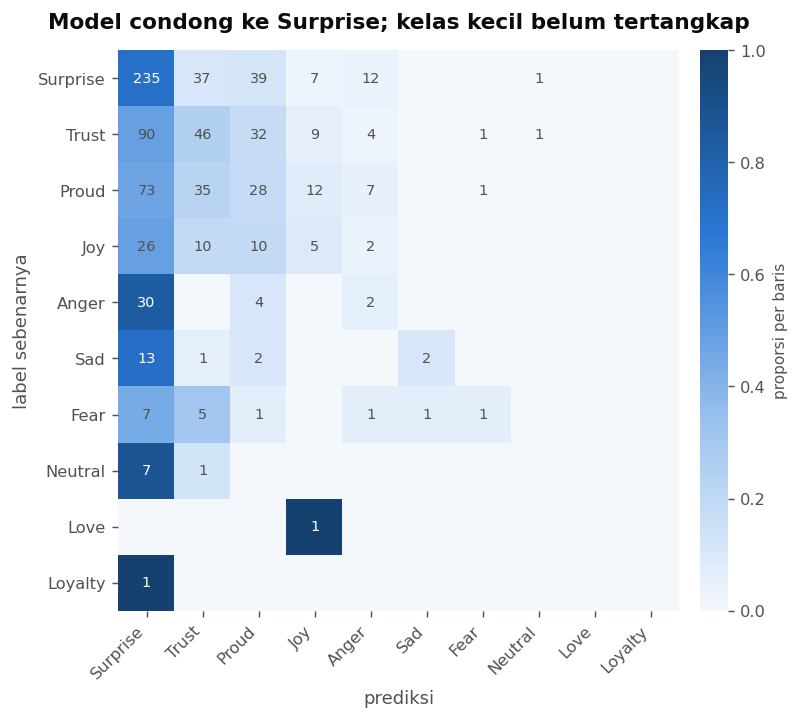

In [6]:
display(Image(str(FIG / "05_confusion_matrix.png")))

---
## 6. Seberapa jauh sebenarnya bisa ditingkatkan

Angka 42% terdengar rendah — sampai dibandingkan dengan batas yang ada.

Ada 11 video yang dipakai pada lebih dari satu baris latih. Menebaknya memakai
label mayoritas dari video itu sendiri — informasi yang model tidak akan pernah
punya — hanya benar **56,1%**. Satu video bahkan dilabeli Trust 7×, Proud 4×,
Surprise 3×, Fear 1×, dan Neutral 1×.

**Anotator tidak sepakat pada video yang sama persis.** Jadi ruang perbaikan yang
tersedia hanya sekitar 15 poin di atas baseline, bukan 59 poin menuju sempurna.

Menyadari batas ini mengubah keputusan proyek: mengejar akurasi lebih jauh
memberi hasil yang jauh lebih kecil daripada memperkuat interpretasi,
reproduktibilitas, dan penyajian.

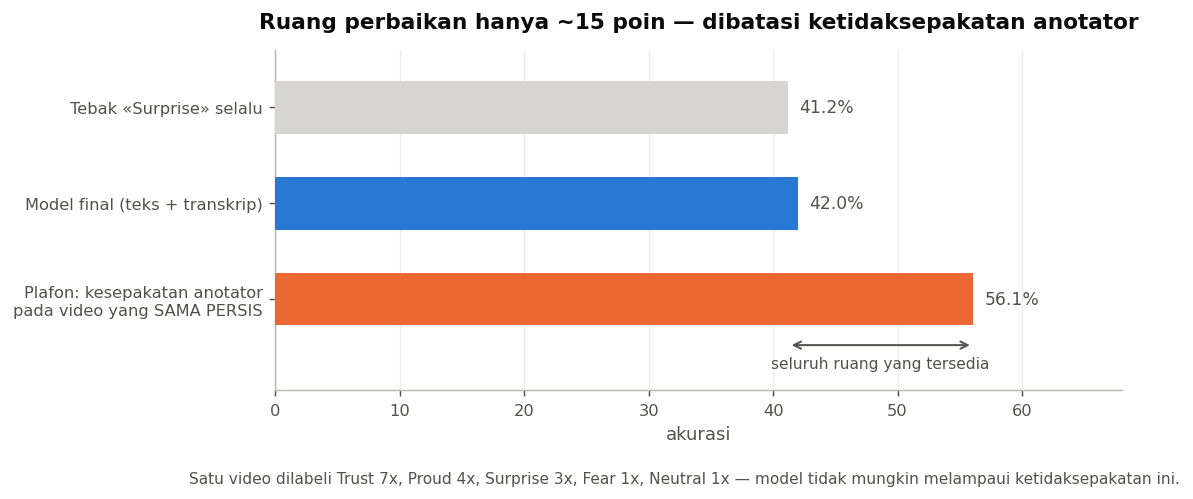

11 video dipakai >1 baris (41 baris)
kesepakatan anotator: 23/41 = 56.1%

contoh terparah:
  [('Trust', 7), ('Proud', 4), ('Surprise', 3), ('Fear', 1), ('Neutral', 1)]
  [('Surprise', 4), ('Trust', 1), ('Proud', 1)]
  [('Surprise', 1), ('Sad', 1), ('Trust', 1)]


In [7]:
display(Image(str(FIG / "06_plafon_derau_label.png")))

import collections
d = collections.defaultdict(list)
for k, e in zip(tr.key, tr.emotion):
    d[k].append(e)
dup = {k: v for k, v in d.items() if len(v) > 1}
baris = sum(len(v) for v in dup.values())
setuju = sum(collections.Counter(v).most_common(1)[0][1] for v in dup.values())
print(f"{len(dup)} video dipakai >1 baris ({baris} baris)")
print(f"kesepakatan anotator: {setuju}/{baris} = {setuju / baris * 100:.1f}%")
print()
print("contoh terparah:")
for k, v in sorted(dup.items(), key=lambda x: -len(x[1]))[:3]:
    print(" ", collections.Counter(v).most_common())


---
## Ringkasan

| Temuan | Konsekuensi |
|---|---|
| Label melacak topik, bukan kata emosi | leksikon dibuang, TF-IDF jadi tulang punggung |
| Fitur numerik menurunkan skor | model final hanya memakai teks |
| Transkrip menambah 25 poin cakupan | konfigurasi pertama yang melewati baseline |
| Anotator hanya sepakat 56% | ruang perbaikan sempit; prioritas dialihkan |

Model final: **TF-IDF (caption + transkrip) → Logistic Regression**,
akurasi **42,0%** dan macro-F1 **0,099** — mengalahkan baseline pada kedua
metrik sekaligus.
